# **Preprocessing**

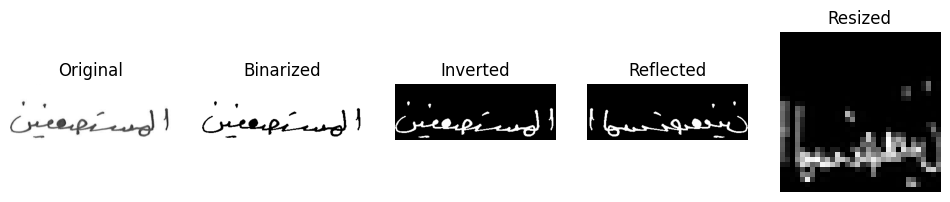

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.0149 - loss: 5.7196 - val_accuracy: 0.0123 - val_loss: 4.4223
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0208 - loss: 4.6262 - val_accuracy: 0.0115 - val_loss: 4.4286
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0240 - loss: 4.4916 - val_accuracy: 0.0188 - val_loss: 4.3382
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0339 - loss: 4.4085 - val_accuracy: 0.0597 - val_loss: 4.2466
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0403 - loss: 4.3143 - val_accuracy: 0.0851 - val_loss: 4.1274
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0476 - loss: 4.2616 - val_accuracy: 0.0933 - val_loss: 4.1003
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0672 - loss: 4.1401 - val_accuracy: 0.1047 - val_loss: 4.0079
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0674 - loss: 4.1272 - val_accuracy: 

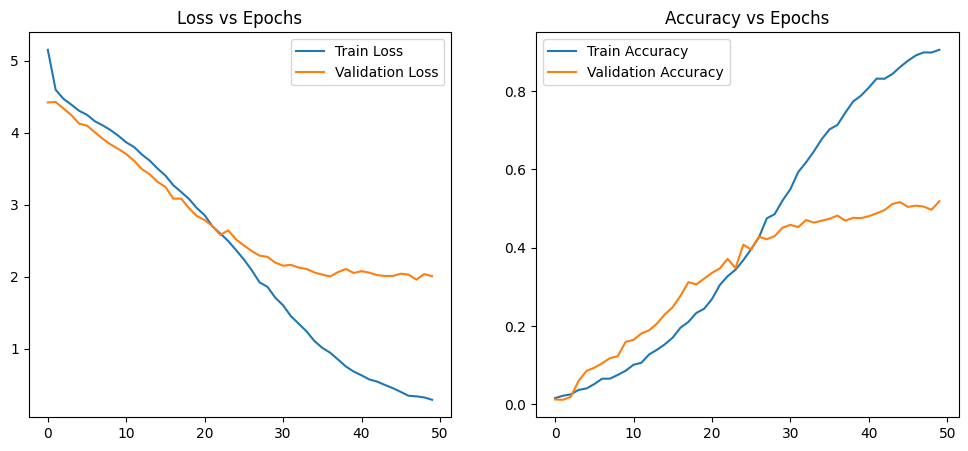

Custom CNN Test Accuracy: 50.49%


<Figure size 640x480 with 0 Axes>

In [6]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, 
                                     BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.transform import resize
from PIL import Image, ImageOps
from tensorflow.keras import layers

# Task 1: Data Preprocessing
def preprocess_image(img_path, img_size=(256, 256)):
    # Load image
    img = Image.open(img_path).convert('L')  # Convert to grayscale
    
    # Binarization
    img_array = np.array(img)
    thresh = threshold_otsu(img_array)
    binary_img = (img_array > thresh).astype(np.uint8) * 255

    # Color inversion
    inverted_img = 255 - binary_img
    # Reflect around the vertical axis
    reflected_img = ImageOps.mirror(Image.fromarray(inverted_img))

    # Resize according to training requirements
    resized_img = reflected_img.resize(img_size, Image.Resampling.LANCZOS)

    return np.array(resized_img)

def visualize_preprocessing(img_path, img_size=(256, 256)):
    # Load and preprocess the image
    img = Image.open(img_path).convert('L')
    img_array = np.array(img)

    # Binarization
    thresh = threshold_otsu(img_array)
    binary_img = (img_array > thresh).astype(np.uint8) * 255

    # Color inversion
    inverted_img = 255 - binary_img

    # Reflection
    reflected_img = ImageOps.mirror(Image.fromarray(inverted_img))

    # Resize
    resized_img = reflected_img.resize(img_size, Image.Resampling.LANCZOS)

    # Plot all steps
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 5, 1)
    plt.title("Original")
    plt.imshow(img_array, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 5, 2)
    plt.title("Binarized")
    plt.imshow(binary_img, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 5, 3)
    plt.title("Inverted")
    plt.imshow(inverted_img, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 5, 4)
    plt.title("Reflected")
    plt.imshow(reflected_img, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 5, 5)
    plt.title("Resized")
    plt.imshow(resized_img, cmap='gray')
    plt.axis('off')

    plt.show()

def load_dataset(data_dir, img_size=(32, 32)):
    X, y = [], []
    for user_folder in os.listdir(data_dir):
        user_path = os.path.join(data_dir, user_folder)
        if os.path.isdir(user_path):
            for img_file in os.listdir(user_path):
                img_path = os.path.join(user_path, img_file)
                processed_img = preprocess_image(img_path, img_size)
                processed_img = np.expand_dims(processed_img, axis=-1)  # Add channel dimension
                X.append(processed_img)
                y.append(user_folder)
    return np.array(X), np.array(y)

# Load dataset
data_dir = "/kaggle/input/isolated-words-per-user/isolated_words_per_user"
img_size = (32, 32)
X, y = load_dataset(data_dir, img_size)
X = X / 255.0  # Normalize pixel values

# Change this to a specific word folder
specific_word_folder = "user001"  # Replace with the desired folder name (e.g., "user001")

# Ensure the folder exists
if specific_word_folder in os.listdir(data_dir):
    specific_word_path = os.path.join(data_dir, specific_word_folder)
    sample_img_path = os.path.join(
        specific_word_path,
        os.listdir(specific_word_path)[60]  # Choose the first image in the folder
    )
    visualize_preprocessing(sample_img_path, img_size)
else:
    print(f"Word folder '{specific_word_folder}' not found in dataset.")


# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y = tf.keras.utils.to_categorical(y)

# Train-validation-test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
input_shape = X_train.shape[1:]
num_classes = y_train.shape[1]

def build_custom_cnn(input_shape=(32, 32, 1), num_classes=28):
    model = Sequential()  # Use Sequential from tensorflow.keras.models

    # First Convolutional Layer
    # model.add(Input(shape=(32, 32, 1)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', input_shape=input_shape, padding='same', strides=(1, 1)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Second Convolutional Layer
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', strides=(1, 1)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Third Convolutional Layer
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', strides=(1, 1)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Flatten the output
    model.add(layers.Flatten())

    # Fully Connected Layers
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.6))
    model.add(layers.Dense(1024, activation='relu'))
    model.add(layers.Dropout(0.6))
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.6))

    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


# Build and compile model

model = build_custom_cnn(input_shape, num_classes)
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train model
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=50, batch_size=32)

# Plot Loss and Accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss vs Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy vs Epochs')
plt.legend()
plt.show()
plt.savefig('task1.png')
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Custom CNN Test Accuracy: {test_accuracy * 100:.2f}%") 

# zoom in in data augmentation determination


Testing with zoom range: 0.1
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - accuracy: 0.0136 - loss: 5.7356 - val_accuracy: 0.0106 - val_loss: 4.4238
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0239 - loss: 4.6284 - val_accuracy: 0.0106 - val_loss: 4.4111
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0237 - loss: 4.5095 - val_accuracy: 0.0278 - val_loss: 4.3315
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0252 - loss: 4.4511 - val_accuracy: 0.0671 - val_loss: 4.2643
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0309 - loss: 4.3692 - val_accuracy: 0.0597 - val_loss: 4.2193
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0397 - loss: 4.3304 - val_accuracy: 0.0696 - val_loss: 4.1506
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0480 - loss: 4.2603 - val_accuracy: 0.0900 - val_loss: 4.1003
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.0521 - loss: 4.2460 - val_accuracy: 0.07

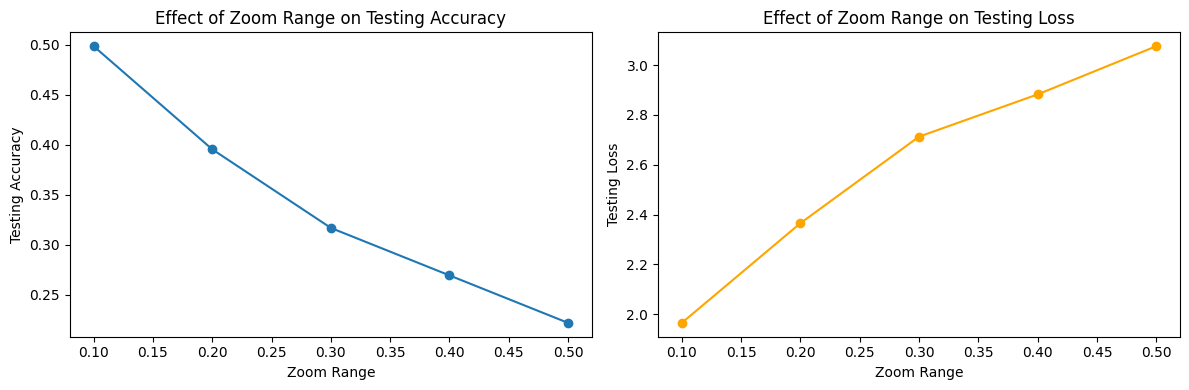

In [8]:
#this part of the code is to determine the correct value we should use for zoomin in data augmentation.


import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, 
                                     BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.transform import resize
from PIL import Image, ImageOps
from tensorflow.keras import layers

# Task 1: Data Preprocessing
def preprocess_image(img_path, img_size=(256, 256)):
    img = Image.open(img_path).convert('L')  # Convert to grayscale
    
    # Binarization
    img_array = np.array(img)
    thresh = threshold_otsu(img_array)
    binary_img = (img_array > thresh).astype(np.uint8) * 255

    # Color inversion
    inverted_img = 255 - binary_img

    # Reflect around the vertical axis
    reflected_img = ImageOps.mirror(Image.fromarray(inverted_img))

    # Resize according to training requirements
    resized_img = reflected_img.resize(img_size, Image.Resampling.LANCZOS)

    return np.array(resized_img)

def load_dataset(data_dir, img_size=(32, 32)):
    X, y = [], []
    for user_folder in os.listdir(data_dir):
        user_path = os.path.join(data_dir, user_folder)
        if os.path.isdir(user_path):
            for img_file in os.listdir(user_path):
                img_path = os.path.join(user_path, img_file)
                processed_img = preprocess_image(img_path, img_size)
                processed_img = np.expand_dims(processed_img, axis=-1)  # Add channel dimension
                X.append(processed_img)
                y.append(user_folder)
    return np.array(X), np.array(y)

# Load dataset
data_dir = "/kaggle/input/isolated-words-per-user/isolated_words_per_user"
img_size = (32, 32)
X, y = load_dataset(data_dir, img_size)
X = X / 255.0  # Normalize pixel values

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y = tf.keras.utils.to_categorical(y)

# Train-validation-test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
input_shape = X_train.shape[1:]
num_classes = y_train.shape[1]

def build_custom_cnn(input_shape=(32, 32, 1), num_classes=82):
    model = Sequential()

    # First Convolutional Layer
    model.add(layers.Conv2D(64, (3, 3), activation='relu', input_shape=input_shape, padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Second Convolutional Layer
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Third Convolutional Layer
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Flatten the output
    model.add(layers.Flatten())

    # Fully Connected Layers
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.6))
    model.add(layers.Dense(1024, activation='relu'))
    model.add(layers.Dropout(0.6))
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.6))

    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Define a range of zoom levels to test
zoom_ranges = [0.1, 0.2, 0.3, 0.4, 0.5]

# Lists to store testing accuracies and losses for each zoom range
testing_accuracies = []
testing_losses = []

# Loop through each zoom range
for zoom_range in zoom_ranges:
    print(f"\nTesting with zoom range: {zoom_range}")

    # Create an ImageDataGenerator with the current zoom range
    datagen = ImageDataGenerator(
        zoom_range=zoom_range,
        fill_mode='nearest'
    )

    # Apply data augmentation to the training data
    augmented_train_data = datagen.flow(X_train, y_train, batch_size=32)

    # Build and compile the model
    model = build_custom_cnn(input_shape, num_classes)
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Train the model
    history = model.fit(
        augmented_train_data,
        validation_data=(X_val, y_val),
        epochs=50,  # Shorter epochs for testing augmentation
        verbose=1
    )

    # Evaluate the model on the test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    testing_losses.append(test_loss)
    testing_accuracies.append(test_accuracy)
    print(f"Zoom Range: {zoom_range}, Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}")

# Plot the testing accuracies and losses
plt.figure(figsize=(12, 4))

# Plot Testing Accuracy
plt.subplot(1, 2, 1)
plt.plot(zoom_ranges, testing_accuracies, marker='o')
plt.xlabel('Zoom Range')
plt.ylabel('Testing Accuracy')
plt.title('Effect of Zoom Range on Testing Accuracy')

# Plot Testing Loss
plt.subplot(1, 2, 2)
plt.plot(zoom_ranges, testing_losses, marker='o', color='orange')
plt.xlabel('Zoom Range')
plt.ylabel('Testing Loss')
plt.title('Effect of Zoom Range on Testing Loss')

plt.tight_layout()
plt.show()


According to the results obtained and sketched, the best value was at 0.1

# Width adjustments


Testing with height shift range: 0.1
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.0128 - loss: 5.6520 - val_accuracy: 0.0123 - val_loss: 4.4233
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0144 - loss: 4.6934 - val_accuracy: 0.0090 - val_loss: 4.4045
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0179 - loss: 4.5222 - val_accuracy: 0.0344 - val_loss: 4.3171
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0271 - loss: 4.4222 - val_accuracy: 0.0745 - val_loss: 4.2624
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0351 - loss: 4.3933 - val_accuracy: 0.0663 - val_loss: 4.2062
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0366 - loss: 4.3511 - val_accuracy: 0.0589 - val_loss: 4.1688
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0375 - loss: 4.3062 - val_accuracy: 0.0597 - val_loss: 4.1577
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0440 - loss: 4.2538 - val_accuracy: 0.06

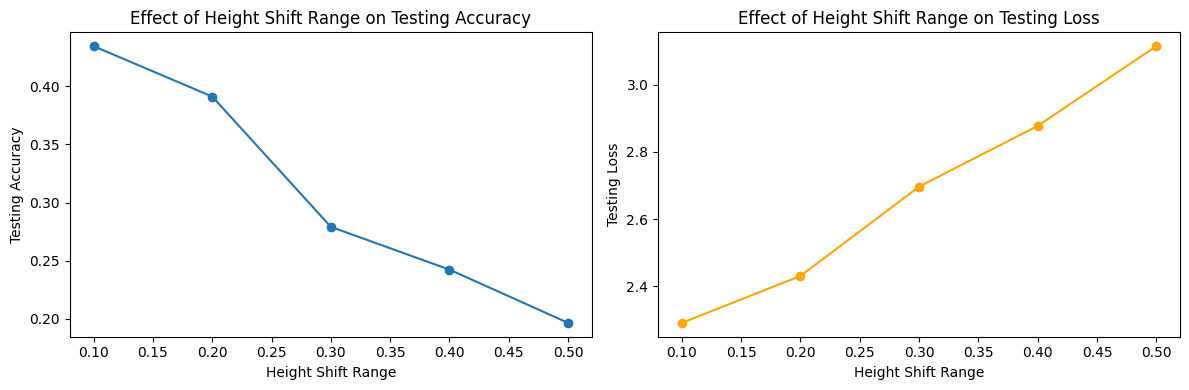

In [9]:
#this part of the code is to determine the effect of width adjustments while keeping the zoom fixed on 0.1 "its best value"
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, 
                                     BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.transform import resize
from PIL import Image, ImageOps
from tensorflow.keras import layers

# Task 1: Data Preprocessing
def preprocess_image(img_path, img_size=(256, 256)):
    img = Image.open(img_path).convert('L')  # Convert to grayscale
    
    # Binarization
    img_array = np.array(img)
    thresh = threshold_otsu(img_array)
    binary_img = (img_array > thresh).astype(np.uint8) * 255

    # Color inversion
    inverted_img = 255 - binary_img

    # Reflect around the vertical axis
    reflected_img = ImageOps.mirror(Image.fromarray(inverted_img))

    # Resize according to training requirements
    resized_img = reflected_img.resize(img_size, Image.Resampling.LANCZOS)

    return np.array(resized_img)

def load_dataset(data_dir, img_size=(32, 32)):
    X, y = [], []
    for user_folder in os.listdir(data_dir):
        user_path = os.path.join(data_dir, user_folder)
        if os.path.isdir(user_path):
            for img_file in os.listdir(user_path):
                img_path = os.path.join(user_path, img_file)
                processed_img = preprocess_image(img_path, img_size)
                processed_img = np.expand_dims(processed_img, axis=-1)  # Add channel dimension
                X.append(processed_img)
                y.append(user_folder)
    return np.array(X), np.array(y)

# Load dataset
data_dir = "/kaggle/input/isolated-words-per-user/isolated_words_per_user"
img_size = (32, 32)
X, y = load_dataset(data_dir, img_size)
X = X / 255.0  # Normalize pixel values

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y = tf.keras.utils.to_categorical(y)

# Train-validation-test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
input_shape = X_train.shape[1:]
num_classes = y_train.shape[1]

def build_custom_cnn(input_shape=(32, 32, 1), num_classes=82):
    model = Sequential()

    # First Convolutional Layer
    model.add(layers.Conv2D(64, (3, 3), activation='relu', input_shape=input_shape, padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Second Convolutional Layer
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Third Convolutional Layer
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Flatten the output
    model.add(layers.Flatten())

    # Fully Connected Layers
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.6))
    model.add(layers.Dense(1024, activation='relu'))
    model.add(layers.Dropout(0.6))
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.6))

    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Define a range of height shifts to test
height_shifts = [0.1, 0.2, 0.3, 0.4, 0.5]

# Lists to store testing accuracies and losses for each height shift range
testing_accuracies = []
testing_losses = []

# Fixed zoom range based on previous results
fixed_zoom_range = 0.1

# Loop through each height shift range
for height_shift in height_shifts:
    print(f"\nTesting with height shift range: {height_shift}")

    # Create an ImageDataGenerator with the current height shift range and fixed zoom range
    datagen = ImageDataGenerator(
        zoom_range=fixed_zoom_range,
        height_shift_range=height_shift,
        fill_mode='nearest'
    )

    # Apply data augmentation to the training data
    augmented_train_data = datagen.flow(X_train, y_train, batch_size=32)

    # Build and compile the model
    model = build_custom_cnn(input_shape, num_classes)
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Train the model
    history = model.fit(
        augmented_train_data,
        validation_data=(X_val, y_val),
        epochs=50,  # Shorter epochs for testing augmentation
        verbose=1
    )

    # Evaluate the model on the test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    testing_losses.append(test_loss)
    testing_accuracies.append(test_accuracy)
    print(f"Height Shift: {height_shift}, Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}")

# Plot the testing accuracies and losses
plt.figure(figsize=(12, 4))

# Plot Testing Accuracy
plt.subplot(1, 2, 1)
plt.plot(height_shifts, testing_accuracies, marker='o')
plt.xlabel('Height Shift Range')
plt.ylabel('Testing Accuracy')
plt.title('Effect of Height Shift Range on Testing Accuracy')

# Plot Testing Loss
plt.subplot(1, 2, 2)
plt.plot(height_shifts, testing_losses, marker='o', color='orange')
plt.xlabel('Height Shift Range')
plt.ylabel('Testing Loss')
plt.title('Effect of Height Shift Range on Testing Loss')

plt.tight_layout()
plt.show()



Testing with width shift range: 0.1
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.0116 - loss: 5.7587 - val_accuracy: 0.0115 - val_loss: 4.4217
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0162 - loss: 4.6904 - val_accuracy: 0.0139 - val_loss: 4.4083
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0193 - loss: 4.5497 - val_accuracy: 0.0286 - val_loss: 4.3406
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0241 - loss: 4.4726 - val_accuracy: 0.0573 - val_loss: 4.3012
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0272 - loss: 4.4243 - val_accuracy: 0.0483 - val_loss: 4.2585
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0337 - loss: 4.3802 - val_accuracy: 0.0614 - val_loss: 4.2516
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0364 - loss: 4.3306 - val_accuracy: 0.0663 - val_loss: 4.2276
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0353 - loss: 4.3214 - val_accuracy: 0.05

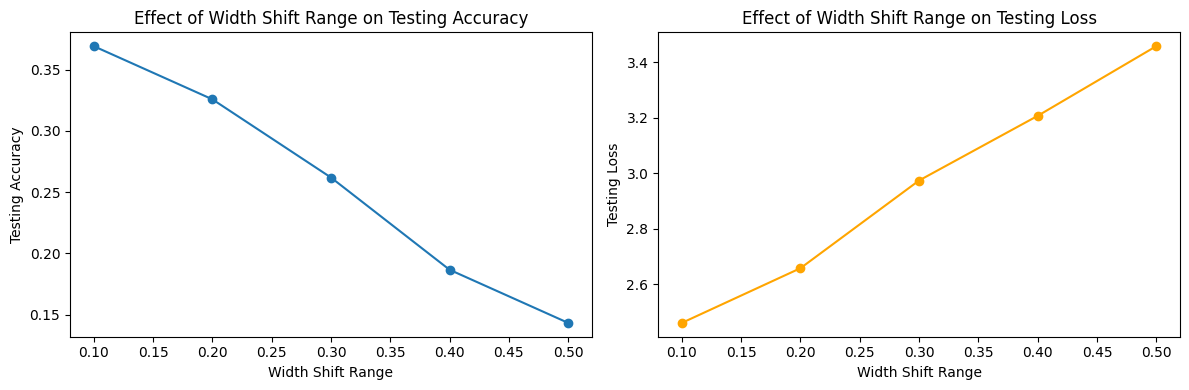

In [11]:
#this part is deducted to see the influence of the width shift on the network
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, 
                                     BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.transform import resize
from PIL import Image, ImageOps
from tensorflow.keras import layers

# Task 1: Data Preprocessing
def preprocess_image(img_path, img_size=(256, 256)):
    img = Image.open(img_path).convert('L')  # Convert to grayscale
    
    # Binarization
    img_array = np.array(img)
    thresh = threshold_otsu(img_array)
    binary_img = (img_array > thresh).astype(np.uint8) * 255

    # Color inversion
    inverted_img = 255 - binary_img

    # Reflect around the vertical axis
    reflected_img = ImageOps.mirror(Image.fromarray(inverted_img))

    # Resize according to training requirements
    resized_img = reflected_img.resize(img_size, Image.Resampling.LANCZOS)

    return np.array(resized_img)

def load_dataset(data_dir, img_size=(32, 32)):
    X, y = [], []
    for user_folder in os.listdir(data_dir):
        user_path = os.path.join(data_dir, user_folder)
        if os.path.isdir(user_path):
            for img_file in os.listdir(user_path):
                img_path = os.path.join(user_path, img_file)
                processed_img = preprocess_image(img_path, img_size)
                processed_img = np.expand_dims(processed_img, axis=-1)  # Add channel dimension
                X.append(processed_img)
                y.append(user_folder)
    return np.array(X), np.array(y)

# Load dataset
data_dir = "/kaggle/input/isolated-words-per-user/isolated_words_per_user"
img_size = (32, 32)
X, y = load_dataset(data_dir, img_size)
X = X / 255.0  # Normalize pixel values

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y = tf.keras.utils.to_categorical(y)

# Train-validation-test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
input_shape = X_train.shape[1:]
num_classes = y_train.shape[1]

def build_custom_cnn(input_shape=(32, 32, 1), num_classes=82):
    model = Sequential()

    # First Convolutional Layer
    model.add(layers.Conv2D(64, (3, 3), activation='relu', input_shape=input_shape, padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Second Convolutional Layer
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Third Convolutional Layer
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Flatten the output
    model.add(layers.Flatten())

    # Fully Connected Layers
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.6))
    model.add(layers.Dense(1024, activation='relu'))
    model.add(layers.Dropout(0.6))
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.6))

    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Define a range of width shifts to test
width_shifts = [0.1, 0.2, 0.3, 0.4, 0.5]

# Lists to store testing accuracies and losses for each width shift range
testing_accuracies = []
testing_losses = []

# Fixed height shift range based on previous results
fixed_height_shift_range = 0.1

# Loop through each width shift range
for width_shift in width_shifts:
    print(f"\nTesting with width shift range: {width_shift}")

    # Create an ImageDataGenerator with the current width shift range and fixed height shift range
    datagen = ImageDataGenerator(
        height_shift_range=fixed_height_shift_range,
        width_shift_range=width_shift,
        fill_mode='nearest'
    )

    # Apply data augmentation to the training data
    augmented_train_data = datagen.flow(X_train, y_train, batch_size=32)

    # Build and compile the model
    model = build_custom_cnn(input_shape, num_classes)
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Train the model
    history = model.fit(
        augmented_train_data,
        validation_data=(X_val, y_val),
        epochs=50,  # Shorter epochs for testing augmentation
        verbose=1
    )

    # Evaluate the model on the test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    testing_losses.append(test_loss)
    testing_accuracies.append(test_accuracy)
    print(f"Width Shift: {width_shift}, Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}")

# Plot the testing accuracies and losses
plt.figure(figsize=(12, 4))

# Plot Testing Accuracy
plt.subplot(1, 2, 1)
plt.plot(width_shifts, testing_accuracies, marker='o')
plt.xlabel('Width Shift Range')
plt.ylabel('Testing Accuracy')
plt.title('Effect of Width Shift Range on Testing Accuracy')

# Plot Testing Loss
plt.subplot(1, 2, 2)
plt.plot(width_shifts, testing_losses, marker='o', color='orange')
plt.xlabel('Width Shift Range')
plt.ylabel('Testing Loss')
plt.title('Effect of Width Shift Range on Testing Loss')

plt.tight_layout()
plt.show()


# Rotation variation effect 

In [ ]:
#this part is to test the effect of rotation variations on the performance of the code.
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, 
                                     BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.transform import resize
from PIL import Image, ImageOps
from tensorflow.keras import layers

# Task 1: Data Preprocessing
def preprocess_image(img_path, img_size=(256, 256)):
    img = Image.open(img_path).convert('L')  # Convert to grayscale
    
    # Binarization
    img_array = np.array(img)
    thresh = threshold_otsu(img_array)
    binary_img = (img_array > thresh).astype(np.uint8) * 255

    # Color inversion
    inverted_img = 255 - binary_img

    # Reflect around the vertical axis
    reflected_img = ImageOps.mirror(Image.fromarray(inverted_img))

    # Resize according to training requirements
    resized_img = reflected_img.resize(img_size, Image.Resampling.LANCZOS)

    return np.array(resized_img)

def load_dataset(data_dir, img_size=(32, 32)):
    X, y = [], []
    for user_folder in os.listdir(data_dir):
        user_path = os.path.join(data_dir, user_folder)
        if os.path.isdir(user_path):
            for img_file in os.listdir(user_path):
                img_path = os.path.join(user_path, img_file)
                processed_img = preprocess_image(img_path, img_size)
                processed_img = np.expand_dims(processed_img, axis=-1)  # Add channel dimension
                X.append(processed_img)
                y.append(user_folder)
    return np.array(X), np.array(y)

# Load dataset
data_dir = "/kaggle/input/isolated-words-per-user/isolated_words_per_user"
img_size = (32, 32)
X, y = load_dataset(data_dir, img_size)
X = X / 255.0  # Normalize pixel values

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y = tf.keras.utils.to_categorical(y)

# Train-validation-test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
input_shape = X_train.shape[1:]
num_classes = y_train.shape[1]

def build_custom_cnn(input_shape=(32, 32, 1), num_classes=82):
    model = Sequential()

    # First Convolutional Layer
    model.add(layers.Conv2D(64, (3, 3), activation='relu', input_shape=input_shape, padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Second Convolutional Layer
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Third Convolutional Layer
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Flatten the output
    model.add(layers.Flatten())

    # Fully Connected Layers
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.6))
    model.add(layers.Dense(1024, activation='relu'))
    model.add(layers.Dropout(0.6))
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.6))

    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Define a range of rotation ranges to test
rotation_ranges = [10, 20, 30, 40, 50]

# Lists to store testing accuracies and losses for each rotation range
testing_accuracies = []
testing_losses = []

# Fixed augmentation parameters
fixed_width_shift = 0.1
fixed_height_shift = 0.1
fixed_zoom_range = 0.1

# Loop through each rotation range
for rotation_range in rotation_ranges:
    print(f"\nTesting with rotation range: {rotation_range}")

    # Create an ImageDataGenerator with the current rotation range and fixed parameters
    datagen = ImageDataGenerator(
        rotation_range=rotation_range,
        width_shift_range=fixed_width_shift,
        height_shift_range=fixed_height_shift,
        zoom_range=fixed_zoom_range,
        fill_mode='nearest'
    )

    # Apply data augmentation to the training data
    augmented_train_data = datagen.flow(X_train, y_train, batch_size=32)

    # Build and compile the model
    model = build_custom_cnn(input_shape, num_classes)
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Train the model
    history = model.fit(
        augmented_train_data,
        validation_data=(X_val, y_val),
        epochs=50, 
        verbose=1
    )

    # Evaluate the model on the test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    testing_losses.append(test_loss)
    testing_accuracies.append(test_accuracy)
    print(f"Rotation: {rotation_range}, Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}")

# Plot the testing accuracies and losses
plt.figure(figsize=(12, 4))

# Plot Testing Accuracy
plt.subplot(1, 2, 1)
plt.plot(rotation_ranges, testing_accuracies, marker='o')
plt.xlabel('Rotation Range (degrees)')
plt.ylabel('Testing Accuracy')
plt.title('Effect of Rotation Range on Testing Accuracy')

# Plot Testing Loss
plt.subplot(1, 2, 2)
plt.plot(rotation_ranges, testing_losses, marker='o', color='orange')
plt.xlabel('Rotation Range (degrees)')
plt.ylabel('Testing Loss')
plt.title('Effect of Rotation Range on Testing Loss')

plt.tight_layout()
plt.show()



Testing with rotation range: 10
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.0121 - loss: 5.7645 - val_accuracy: 0.0123 - val_loss: 4.4105
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0159 - loss: 4.6669 - val_accuracy: 0.0123 - val_loss: 4.3958
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0266 - loss: 4.5093 - val_accuracy: 0.0401 - val_loss: 4.3207
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0183 - loss: 4.4694 - val_accuracy: 0.0581 - val_loss: 4.2653
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0341 - loss: 4.4101 - val_accuracy: 0.0524 - val_loss: 4.2476
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0300 - loss: 4.3998 - val_accuracy: 0.0507 - val_loss: 4.2207
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0356 - loss: 4.3200 - val_accuracy: 0.0548 - val_loss: 4.2057
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0391 - loss: 4.2947 - val_accuracy: 0.05

# Shear Range


Testing with shear range: 0.1
Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


179/179 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.0127 - loss: 5.7750 - val_accuracy: 0.0115 - val_loss: 4.4210
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0172 - loss: 4.6842 - val_accuracy: 0.0115 - val_loss: 4.4079
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0217 - loss: 4.5449 - val_accuracy: 0.0278 - val_loss: 4.3621
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0236 - loss: 4.4752 - val_accuracy: 0.0524 - val_loss: 4.3135
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0275 - loss: 4.4110 - val_accuracy: 0.0516 - val_loss: 4.2918
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0309 - loss: 4.3965 - val_accuracy: 0.0434 - val_loss: 4.2669
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0328 - loss: 4.3659 - val_accuracy: 0.0426 - val_loss: 4.2599
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0433 - loss: 4.2868 - val_accuracy: 0.05

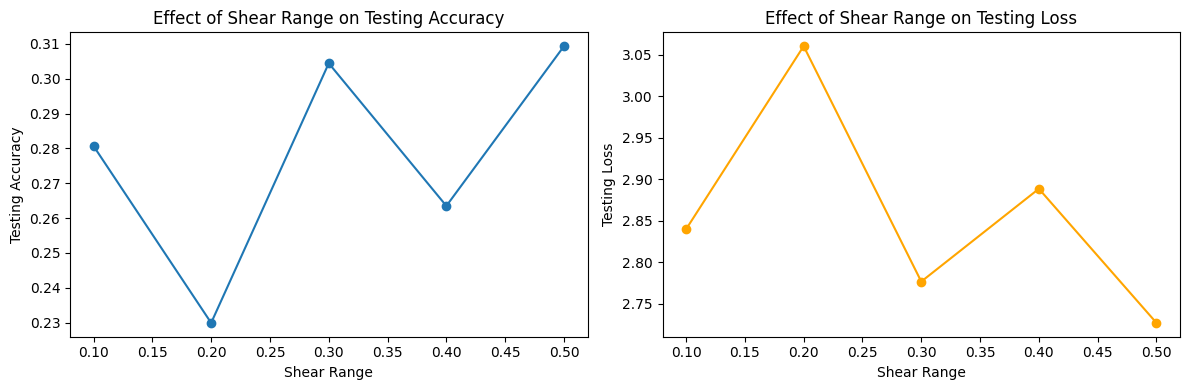

In [13]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout, 
                                     BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.transform import resize
from PIL import Image, ImageOps
from tensorflow.keras import layers

# Task 1: Data Preprocessing
def preprocess_image(img_path, img_size=(256, 256)):
    img = Image.open(img_path).convert('L')  # Convert to grayscale
    
    # Binarization
    img_array = np.array(img)
    thresh = threshold_otsu(img_array)
    binary_img = (img_array > thresh).astype(np.uint8) * 255

    # Color inversion
    inverted_img = 255 - binary_img

    # Reflect around the vertical axis
    reflected_img = ImageOps.mirror(Image.fromarray(inverted_img))

    # Resize according to training requirements
    resized_img = reflected_img.resize(img_size, Image.Resampling.LANCZOS)

    return np.array(resized_img)

def load_dataset(data_dir, img_size=(32, 32)):
    X, y = [], []
    for user_folder in os.listdir(data_dir):
        user_path = os.path.join(data_dir, user_folder)
        if os.path.isdir(user_path):
            for img_file in os.listdir(user_path):
                img_path = os.path.join(user_path, img_file)
                processed_img = preprocess_image(img_path, img_size)
                processed_img = np.expand_dims(processed_img, axis=-1)  # Add channel dimension
                X.append(processed_img)
                y.append(user_folder)
    return np.array(X), np.array(y)

# Load dataset
data_dir = "/kaggle/input/isolated-words-per-user/isolated_words_per_user"
img_size = (32, 32)
X, y = load_dataset(data_dir, img_size)
X = X / 255.0  # Normalize pixel values

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y = tf.keras.utils.to_categorical(y)

# Train-validation-test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
input_shape = X_train.shape[1:]
num_classes = y_train.shape[1]

def build_custom_cnn(input_shape=(32, 32, 1), num_classes=82):
    model = Sequential()

    # First Convolutional Layer
    model.add(layers.Conv2D(64, (3, 3), activation='relu', input_shape=input_shape, padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Second Convolutional Layer
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Third Convolutional Layer
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.BatchNormalization())

    # Flatten the output
    model.add(layers.Flatten())

    # Fully Connected Layers
    model.add(layers.Dense(4096, activation='relu'))
    model.add(layers.Dropout(0.6))
    model.add(layers.Dense(1024, activation='relu'))
    model.add(layers.Dropout(0.6))
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.6))

    # Output Layer
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Define a range of shear intensities to test
shear_ranges = [0.1, 0.2, 0.3, 0.4, 0.5]

# Lists to store testing accuracies and losses for each shear intensity
testing_accuracies = []
testing_losses = []

# Fixed augmentation parameters
fixed_rotation = 10
fixed_width_shift = 0.1
fixed_height_shift = 0.1
fixed_zoom_range = 0.1

# Loop through each shear range
for shear_range in shear_ranges:
    print(f"\nTesting with shear range: {shear_range}")

    # Create an ImageDataGenerator with the current shear range and fixed parameters
    datagen = ImageDataGenerator(
        shear_range=shear_range,
        rotation_range=fixed_rotation,
        width_shift_range=fixed_width_shift,
        height_shift_range=fixed_height_shift,
        zoom_range=fixed_zoom_range,
        fill_mode='nearest'
    )

    # Apply data augmentation to the training data
    augmented_train_data = datagen.flow(X_train, y_train, batch_size=32)

    # Build and compile the model
    model = build_custom_cnn(input_shape, num_classes)
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    # Train the model
    history = model.fit(
        augmented_train_data,
        validation_data=(X_val, y_val),
        epochs=50, 
        verbose=1
    )

    # Evaluate the model on the test set
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    testing_losses.append(test_loss)
    testing_accuracies.append(test_accuracy)
    print(f"Shear Range: {shear_range}, Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}")

# Plot the testing accuracies and losses
plt.figure(figsize=(12, 4))

# Plot Testing Accuracy
plt.subplot(1, 2, 1)
plt.plot(shear_ranges, testing_accuracies, marker='o')
plt.xlabel('Shear Range')
plt.ylabel('Testing Accuracy')
plt.title('Effect of Shear Range on Testing Accuracy')

# Plot Testing Loss
plt.subplot(1, 2, 2)
plt.plot(shear_ranges, testing_losses, marker='o', color='orange')
plt.xlabel('Shear Range')
plt.ylabel('Testing Loss')
plt.title('Effect of Shear Range on Testing Loss')

plt.tight_layout()
plt.show()


In [14]:
aug = ImageDataGenerator(
    rotation_range=10,  # Reduced rotation
    width_shift_range=0.1,  # Reduced width shift
    height_shift_range=0.1,  # Reduced height shift
    shear_range=0.3,  # Reduced shear
    zoom_range=0.1,  # Reduced zoom
    fill_mode='nearest')

aug_train = aug.flow(X_train, y_train, batch_size=32)

# Task 2 
after testing multiple values for using the most suitable for data augmentation. Task 2 is made to test and retrain the dataset according the values.

Epoch 1/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8090 - loss: 0.6897 - val_accuracy: 0.6833 - val_loss: 1.2545
Epoch 2/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8086 - loss: 0.6562 - val_accuracy: 0.6989 - val_loss: 1.1650
Epoch 3/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8168 - loss: 0.6542 - val_accuracy: 0.6841 - val_loss: 1.2092
Epoch 4/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8069 - loss: 0.6371 - val_accuracy: 0.6931 - val_loss: 1.1562
Epoch 5/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8222 - loss: 0.6110 - val_accuracy: 0.6105 - val_loss: 1.6156
Epoch 6/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8221 - loss: 0.5861 - val_accuracy: 0.6972 - val_loss: 1.1676
Epoch 7/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.8229 - loss: 0.6056 - val_accuracy: 0.6989 - val_loss: 1.1670
Epoch 8/50
179/179 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8366 - loss: 0.5394 - val_accu

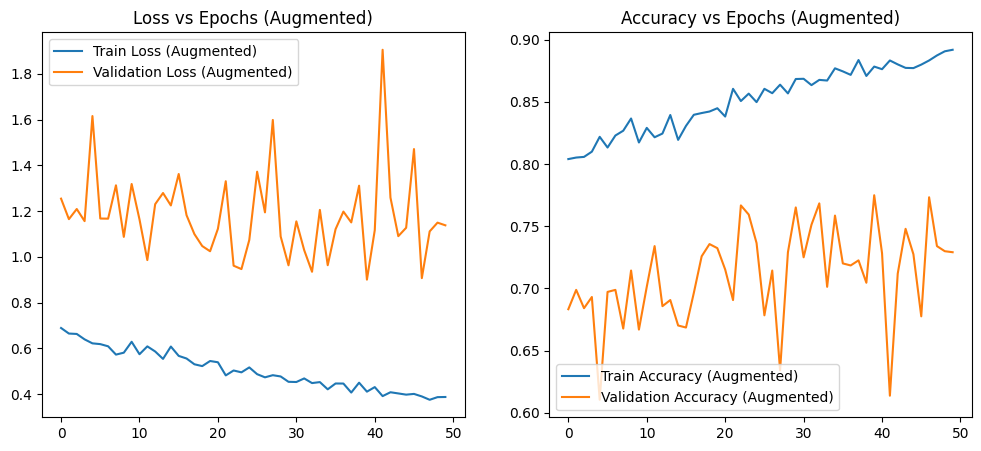

Augmented CNN Test Accuracy: 69.80%


In [17]:
# Task 2: Data Augmentation and Retrain

# Retrain model with augmentation
history_aug = model.fit(aug_train, validation_data=(X_val, y_val),
                        epochs=50, batch_size=32)

# Plot Loss and Accuracy for Augmented Data
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_aug.history['loss'], label='Train Loss (Augmented)')
plt.plot(history_aug.history['val_loss'], label='Validation Loss (Augmented)')
plt.title('Loss vs Epochs (Augmented)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_aug.history['accuracy'], label='Train Accuracy (Augmented)')
plt.plot(history_aug.history['val_accuracy'], label='Validation Accuracy (Augmented)')
plt.title('Accuracy vs Epochs (Augmented)')
plt.legend()
plt.show()
aug_test_loss, aug_test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Augmented CNN Test Accuracy: {aug_test_accuracy * 100:.2f}%")

# Task 3 
I chose ResNet50 CNN and trained it with data augmentation.

Using device: cuda


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [1/50], Train Loss: 4.3362, Train Acc: 4.54%, Val Loss: 3.8525, Val Acc: 10.24%
Epoch [2/50], Train Loss: 3.5930, Train Acc: 11.54%, Val Loss: 3.6701, Val Acc: 13.92%
Epoch [3/50], Train Loss: 3.1984, Train Acc: 17.54%, Val Loss: 3.2085, Val Acc: 18.18%
Epoch [4/50], Train Loss: 2.9098, Train Acc: 22.77%, Val Loss: 2.9726, Val Acc: 21.38%
Epoch [5/50], Train Loss: 2.6662, Train Acc: 27.86%, Val Loss: 2.9418, Val Acc: 23.18%
Epoch [6/50], Train Loss: 2.4894, Train Acc: 32.32%, Val Loss: 2.7462, Val Acc: 27.60%
Epoch [7/50], Train Loss: 2.2983, Train Acc: 37.40%, Val Loss: 2.4865, Val Acc: 33.33%
Epoch [8/50], Train Loss: 2.0995, Train Acc: 41.25%, Val Loss: 2.3807, Val Acc: 34.81%
Epoch [9/50], Train Loss: 1.9100, Train Acc: 46.14%, Val Loss: 2.2698, Val Acc: 37.84%
Epoch [10/50], Train Loss: 1.7552, Train Acc: 50.65%, Val Loss: 2.5707, Val Acc: 32.68%
Epoch [11/50], Train Loss: 1.5848, Train Acc: 55.40%, Val Loss: 2.1728, Val Acc: 40.62%
Epoch [12/50], Train Loss: 1.4629, Train A

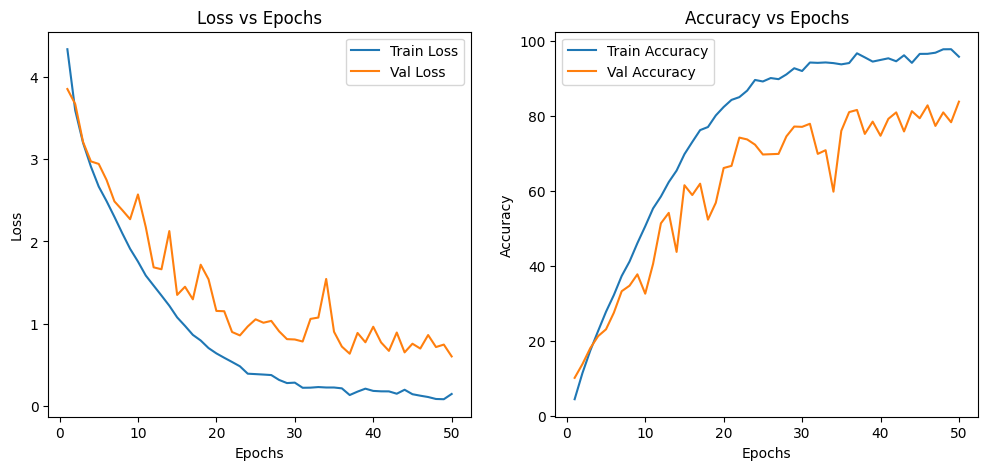

Test Accuracy: 83.24%


In [16]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from skimage.filters import threshold_otsu

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Parameters
batch_size = 32
num_classes = 82
num_epochs = 50
learning_rate = 1e-4
img_size = (256, 256)

# Task 1: Data Preprocessing
def preprocess_image(img_path, img_size=(256, 256)):
    # Load image
    img = Image.open(img_path).convert('L')  # Convert to grayscale

    # Binarization
    img_array = np.array(img)
    thresh = threshold_otsu(img_array)
    binary_img = (img_array > thresh).astype(np.uint8) * 255

    # Color inversion
    inverted_img = 255 - binary_img

    # Reflect around the vertical axis
    reflected_img = ImageOps.mirror(Image.fromarray(inverted_img))

    # Resize
    resized_img = reflected_img.resize(img_size, Image.Resampling.LANCZOS)

    return np.array(resized_img)

# Custom Dataset Class
class HandwritingDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = []
        self.labels = []
        self.transform = transform
        for label in os.listdir(data_dir):
            label_dir = os.path.join(data_dir, label)
            if os.path.isdir(label_dir):
                for img_file in os.listdir(label_dir):
                    img_path = os.path.join(label_dir, img_file)
                    self.data.append(preprocess_image(img_path, img_size))
                    self.labels.append(label)
        self.encoder = LabelEncoder()
        self.labels = self.encoder.fit_transform(self.labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx]
        label = self.labels[idx]
        img = np.array(img, dtype=np.float32) / 255.0  # Scale to [0, 1]
        img = np.stack([img, img, img], axis=-1)  # Convert grayscale to RGB
        if self.transform:
            img = self.transform(Image.fromarray((img * 255).astype(np.uint8)))  # Apply transform
        return img, label

# Updated Transform for Training (Data Augmentation)
train_transform = transforms.Compose([
    transforms.RandomRotation(15),  # Rotation range
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Width and height shift
    transforms.RandomAffine(degrees=0, shear=10),  # Shear transformation
    transforms.RandomResizedCrop(img_size[0], scale=(0.9, 1.1)),  # Zoom in/out
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize
])

# Validation and Testing Transform (no augmentation, just normalization)
val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Applying the transforms to the datasets
train_dataset = HandwritingDataset(data_dir, transform=train_transform)
val_dataset = HandwritingDataset(data_dir, transform=val_test_transform)
test_dataset = HandwritingDataset(data_dir, transform=val_test_transform)

# Train-validation-test split
train_size = int(0.7 * len(train_dataset))
val_size = int(0.15 * len(train_dataset))
test_size = len(train_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



# Load ResNet18 Model Without Pre-trained Weights
resnet50 = models.resnet50(pretrained=False)

# Modify the final fully connected layer
num_features = resnet50.fc.in_features
resnet18.fc = nn.Linear(num_features, num_classes)

# Move model to GPU/CPU
resnet50 = resnet50.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(resnet50.parameters(), lr=learning_rate)

# Training Function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device).float(), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)
            train_loss += loss.item()

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Accuracy
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(correct / total * 100)

        # Validation Phase
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device).float(), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(correct / total * 100)

        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.2f}%, "
              f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracies[-1]:.2f}%")

    return train_losses, train_accuracies, val_losses, val_accuracies

# Train the model
train_losses, train_accuracies, val_losses, val_accuracies = train_model(
    resnet50, train_loader, val_loader, criterion, optimizer, num_epochs
)

# Plot Loss and Accuracy
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()

plt.show()

# Test the model
resnet50.eval()
test_loss, correct, total = 0, 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device).float(), labels.to(device)

        outputs = resnet50(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total * 100
print(f"Test Accuracy: {test_accuracy:.2f}%") 

# Task 4
I again chose ResNet and applied transfer learning to fine tune and pretrain the dataset. 

Using device: cuda


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
<ipython-input-4-acbedd90d7f4>:101: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the function

Epoch [1/50], Train Loss: 4.1098, Train Acc: 7.89%, Val Loss: 3.6022, Val Acc: 17.94%
Epoch [2/50], Train Loss: 3.4478, Train Acc: 21.30%, Val Loss: 2.9399, Val Acc: 34.81%
Epoch [3/50], Train Loss: 2.9741, Train Acc: 32.65%, Val Loss: 2.6019, Val Acc: 45.21%
Epoch [4/50], Train Loss: 2.5309, Train Acc: 45.86%, Val Loss: 2.1948, Val Acc: 55.61%
Epoch [5/50], Train Loss: 2.2164, Train Acc: 56.32%, Val Loss: 2.3002, Val Acc: 52.66%
Epoch [6/50], Train Loss: 1.9158, Train Acc: 66.53%, Val Loss: 2.0493, Val Acc: 59.62%
Epoch [7/50], Train Loss: 1.6977, Train Acc: 74.32%, Val Loss: 1.7065, Val Acc: 71.91%
Epoch [8/50], Train Loss: 1.5477, Train Acc: 79.02%, Val Loss: 1.5384, Val Acc: 76.17%
Epoch [9/50], Train Loss: 1.3992, Train Acc: 85.19%, Val Loss: 1.4915, Val Acc: 78.71%
Epoch [10/50], Train Loss: 1.3150, Train Acc: 87.72%, Val Loss: 1.4719, Val Acc: 79.69%
Epoch [11/50], Train Loss: 1.1403, Train Acc: 94.09%, Val Loss: 1.2470, Val Acc: 87.80%
Epoch [12/50], Train Loss: 1.0782, Train A

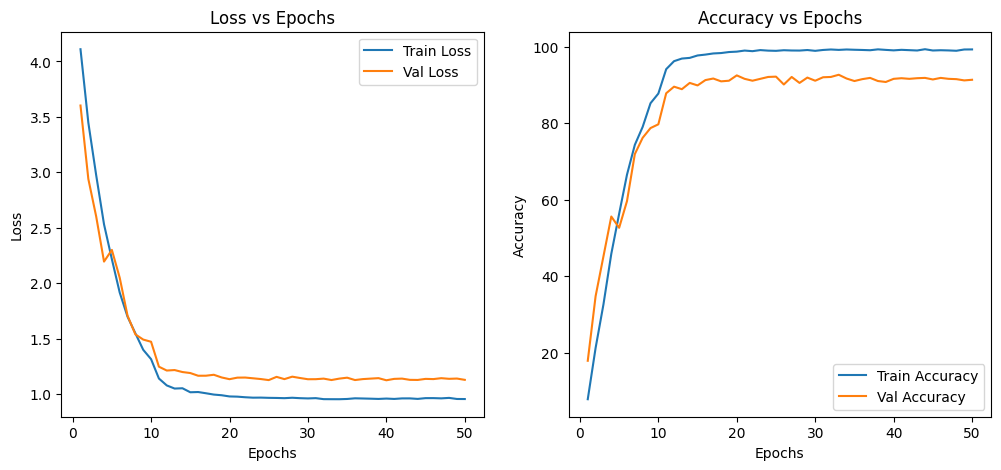

Test Accuracy: 91.33%


In [4]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from skimage.filters import threshold_otsu

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Parameters
batch_size = 32
num_classes = 82
num_epochs = 50
learning_rate = 1e-4
img_size = (256, 256)

# Preprocessing function
def preprocess_image(img_path, img_size=(256, 256)):
    img = Image.open(img_path).convert('L')  # Convert to grayscale
    img_array = np.array(img)
    thresh = threshold_otsu(img_array)
    binary_img = (img_array > thresh).astype(np.uint8) * 255
    inverted_img = 255 - binary_img
    reflected_img = ImageOps.mirror(Image.fromarray(inverted_img))
    resized_img = reflected_img.resize(img_size, Image.Resampling.LANCZOS)
    return np.array(resized_img)

# Custom Dataset Class
class HandwritingDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data = []
        self.labels = []
        self.transform = transform
        for root, dirs, files in os.walk(data_dir):  # Recursively traverse directories
            for file in files:
                if file.endswith(('.png', '.jpg', '.jpeg')):  # Filter image files
                    img_path = os.path.join(root, file)
                    label = os.path.basename(root)  # Use folder name as label
                    self.data.append(preprocess_image(img_path, img_size))
                    self.labels.append(label)
        self.encoder = LabelEncoder()
        self.labels = self.encoder.fit_transform(self.labels)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = self.data[idx]
        label = self.labels[idx]
        img = np.array(img, dtype=np.float32) / 255.0  # Scale to [0, 1]
        img = np.stack([img, img, img], axis=-1)  # Convert grayscale to RGB
        if self.transform:
            img = self.transform(Image.fromarray((img * 255).astype(np.uint8)))
        return img, label

# Data Augmentation
train_transform = transforms.Compose([
    transforms.RandomRotation(15),  # Rotation range
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Width and height shift
    transforms.RandomAffine(degrees=0, shear=10),  # Shear transformation
    transforms.RandomResizedCrop(img_size[0], scale=(0.9, 1.1)),  # Zoom in/out
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize
])


val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Dataset Paths
data_dir = "/kaggle/input/isolated-words-per-user/isolated_words_per_user"  # Update path if needed
train_dataset = HandwritingDataset(data_dir, transform=train_transform)
val_dataset = HandwritingDataset(data_dir, transform=val_test_transform)
test_dataset = HandwritingDataset(data_dir, transform=val_test_transform)

# Train-validation-test split
train_size = int(0.7 * len(train_dataset))
val_size = int(0.15 * len(train_dataset))
test_size = len(train_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    train_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Load ResNet50 with Pretrained Weights
# Load ResNet50 with Pretrained Weights
# Load ResNet50 with Pretrained Weights
pretrained_weights_path = "/kaggle/input/resnet50-0676ba61/resnet50-0676ba61.pth"
resnet50 = models.resnet50(pretrained=False)
resnet50.load_state_dict(torch.load(pretrained_weights_path))

# Fine-Tuning: Unfreeze Specific Layers
for name, param in resnet50.named_parameters():
    if 'layer2' in name or 'layer3' in name or 'layer4' in name or 'fc' in name:
        param.requires_grad = True
    else:
        param.requires_grad = False
# Modify Fully Connected Layer
# Modify Fully Connected Layer
num_features = resnet50.fc.in_features
resnet50.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, num_classes)
)

# Initialize Weights in Fully Connected Layer
for layer in resnet50.fc:
    if isinstance(layer, nn.Linear):  # Initialize only Linear layers
        nn.init.xavier_uniform_(layer.weight)
        nn.init.zeros_(layer.bias)


resnet50 = resnet50.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet50.parameters()), lr=1e-4)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

# Training Function
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            train_loss += loss.item()
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        scheduler.step()

        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(correct / total * 100)

        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(correct / total * 100)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.4f}, "
              f"Train Acc: {train_accuracies[-1]:.2f}%, Val Loss: {val_losses[-1]:.4f}, "
              f"Val Acc: {val_accuracies[-1]:.2f}%")

    return train_losses, train_accuracies, val_losses, val_accuracies

# Train the Model
train_losses, train_accuracies, val_losses, val_accuracies = train_model(
    resnet50, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs)

# Plot Loss and Accuracy
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss vs Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.legend()

plt.show()

# Evaluate on Test Set
resnet50.eval()
test_loss, correct, total = 0, 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = resnet50(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_accuracy = correct / total * 100
print(f"Test Accuracy: {test_accuracy:.2f}%")
